In [1]:
# Assignment 2: Sanskrit-to-English Neural Machine Translation

In [2]:
## Cell 1 — Install Dependencies

In [3]:
!pip install torch sentencepiece nltk bert-score tqdm pandas numpy matplotlib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.9 MB/s eta 0:00:00


In [4]:
## Cell 2 — Imports & Reproducibility

In [5]:
import os, time, math, random, re, unicodedata
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import sentencepiece as spm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Device:', DEVICE)

Device: cuda


In [6]:
## Cell 3 — Load Dataset

In [7]:
DATA_DIR = '.'

def load_data(split):
    suffix = '10000' if split == 'train' else '1000'
    df_sa = pd.read_csv(f'{DATA_DIR}/{split}_sa_{suffix}.csv')
    df_en = pd.read_csv(f'{DATA_DIR}/{split}_en_{suffix}.csv')
    df = df_sa.merge(df_en, on='Source_id')
    df = df.dropna(subset=['Sentence_sa', 'Sentence_en']).reset_index(drop=True)
    df['Sentence_sa'] = df['Sentence_sa'].astype(str).str.strip()
    df['Sentence_en'] = df['Sentence_en'].astype(str).str.strip()
    return df

train_df = load_data('train')
dev_df   = load_data('dev')
test_df  = load_data('test')
print(f'Train: {len(train_df)}, Dev: {len(dev_df)}, Test: {len(test_df)}')
train_df.head(3)

Train: 10000, Dev: 1000, Test: 1000


,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."


In [8]:
## Cell 4 — Text Preprocessing & SentencePiece BPE Tokenizer

In [9]:
def clean_text(text):
    text = unicodedata.normalize('NFC', str(text).strip())
    text = re.sub(r'\s+', ' ', text)
    return text

# Use train+dev for tokenizer training (no leakage: tokenizer is unsupervised)
all_sa = train_df['Sentence_sa'].tolist() + dev_df['Sentence_sa'].tolist()
all_en = train_df['Sentence_en'].tolist() + dev_df['Sentence_en'].tolist()

with open('corpus_sa.txt', 'w', encoding='utf-8') as f:
    f.writelines(clean_text(s) + '\n' for s in all_sa)
with open('corpus_en.txt', 'w', encoding='utf-8') as f:
    f.writelines(clean_text(s) + '\n' for s in all_en)

# Vocab sizes tuned for corpus size (~11k sentences each)
# Sanskrit is morphologically rich -> smaller vocab reduces sparsity
SRC_VOCAB = 4000
TGT_VOCAB = 6000

spm.SentencePieceTrainer.train(
    input='corpus_sa.txt',
    model_prefix='sp_sa',
    vocab_size=SRC_VOCAB,
    character_coverage=1.0, # 1.0 to preserve all Devanagari characters
    model_type='bpe',
    pad_id=0, unk_id=1, bos_id=2, eos_id=3
)

spm.SentencePieceTrainer.train(
    input='corpus_en.txt',
    model_prefix='sp_en',
    vocab_size=TGT_VOCAB,
    character_coverage=1.0,
    model_type='bpe',
    pad_id=0, unk_id=1, bos_id=2, eos_id=3
)

sp_sa = spm.SentencePieceProcessor(model_file='sp_sa.model')
sp_en = spm.SentencePieceProcessor(model_file='sp_en.model')
print('SA vocab:', sp_sa.vocab_size(), '  EN vocab:', sp_en.vocab_size())


SA vocab: 4000   EN vocab: 6000


In [10]:
## Cell 5 — Dataset & DataLoader

In [11]:
PAD_IDX = 0
BOS_IDX = 2
EOS_IDX = 3

# 99th percentile of sentence lengths is ~27/39 word-tokens.
# After BPE, subword tokens are ~1.5x word tokens, so 80 covers >99% of sentences.

MAX_SRC_LEN = 80
MAX_TGT_LEN = 80

class TranslationDataset(Dataset):

    def __init__(self, df, sp_src, sp_tgt):
        self.pairs = []
        for _, row in df.iterrows():

            src_ids = sp_src.encode(clean_text(row['Sentence_sa']), out_type=int)[:MAX_SRC_LEN]
            tgt_ids = ([BOS_IDX]
                       + sp_tgt.encode(clean_text(row['Sentence_en']), out_type=int)[:MAX_TGT_LEN - 2]
                       + [EOS_IDX])

            if len(src_ids) == 0 or len(tgt_ids) <= 2:
                continue

            self.pairs.append((torch.tensor(src_ids, dtype=torch.long),
                               torch.tensor(tgt_ids, dtype=torch.long)))

    def __len__(self):        return len(self.pairs)
    def __getitem__(self, i): return self.pairs[i]


def collate_fn(batch):

    src_batch, tgt_batch = zip(*batch)
    src_padded = pad_sequence(src_batch, batch_first=True, padding_value=PAD_IDX)
    tgt_padded = pad_sequence(tgt_batch, batch_first=True, padding_value=PAD_IDX)
    return src_padded, tgt_padded

BATCH_SIZE = 64
train_dataset = TranslationDataset(train_df, sp_sa, sp_en)
dev_dataset   = TranslationDataset(dev_df,   sp_sa, sp_en)



train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn, drop_last=False)

dev_loader   = DataLoader(dev_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn)

print(f'Train pairs: {len(train_dataset)}, Dev pairs: {len(dev_dataset)}')
print(f'Train batches: {len(train_loader)}, Dev batches: {len(dev_loader)}')

Train pairs: 10000, Dev pairs: 1000
Train batches: 157, Dev batches: 16


In [12]:
## Cell 6 — Model Architecture: BiGRU Encoder + Bahdanau Attention + GRU Decoder

In [13]:
class BahdanauAttention(nn.Module):

    """Additive (Bahdanau) attention."""
    def __init__(self, enc_hid, dec_hid):
        super().__init__()
        self.W_enc = nn.Linear(enc_hid * 2, dec_hid, bias=False)
        self.W_dec = nn.Linear(dec_hid, dec_hid, bias=False)
        self.v     = nn.Linear(dec_hid, 1, bias=False)

    def forward(self, dec_hidden, enc_outputs, src_mask):

        # dec_hidden:  [B, dec_hid]
        # enc_outputs: [B, src_len, enc_hid*2]
        # src_mask:    [B, src_len]  (True = real token)
        energy = torch.tanh(
            self.W_enc(enc_outputs) +                         # [B, src_len, dec_hid]
            self.W_dec(dec_hidden).unsqueeze(1)               # [B, 1,       dec_hid]
        )                                                     # broadcast -> [B, src_len, dec_hid]
        scores = self.v(energy).squeeze(-1)                   # [B, src_len]
        scores = scores.masked_fill(~src_mask, float('-inf'))
        return F.softmax(scores, dim=1)                       # [B, src_len]

class Encoder(nn.Module):

    def __init__(self, vocab_size, emb_dim, hid_dim, n_layers, dropout):

        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.GRU(
            emb_dim, hid_dim, num_layers=n_layers,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0,
            batch_first=True
        )
        # Project bidirectional hidden to decoder hidden size
        self.fc      = nn.Linear(hid_dim * 2, hid_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):

        # src: [B, src_len]
        emb = self.dropout(self.embedding(src))           # [B, src_len, emb_dim]
        enc_out, hidden = self.rnn(emb)
        # enc_out: [B, src_len, hid*2]
        # hidden:  [n_layers*2, B, hid]  -> take last layer forward+backward
        hidden = torch.tanh(self.fc(
            torch.cat([hidden[-2], hidden[-1]], dim=1)     # [B, hid*2]
        ))                                                 # [B, hid]
        src_mask = (src != PAD_IDX)                       # [B, src_len]
        return enc_out, hidden, src_mask

class Decoder(nn.Module):

    def __init__(self, vocab_size, emb_dim, enc_hid, dec_hid, n_layers, dropout):

        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.attention = BahdanauAttention(enc_hid, dec_hid)
        self.rnn = nn.GRU(
            emb_dim + enc_hid * 2, dec_hid,
            num_layers=n_layers,
            dropout=dropout if n_layers > 1 else 0.0,
            batch_first=True
        )

        # Deep output: combine dec output + context + embedding (Lu et al.)
        self.out_proj = nn.Linear(dec_hid + enc_hid * 2 + emb_dim, vocab_size)
        self.dropout  = nn.Dropout(dropout)

    def forward_step(self, tok, hidden, enc_out, src_mask):

        # tok: [B]  hidden: [n_layers, B, dec_hid]
        emb     = self.dropout(self.embedding(tok.unsqueeze(1)))   # [B, 1, emb]
        attn    = self.attention(hidden[-1], enc_out, src_mask)    # [B, src_len]
        context = torch.bmm(attn.unsqueeze(1), enc_out)            # [B, 1, enc_hid*2]
        rnn_in  = torch.cat([emb, context], dim=2)                 # [B, 1, emb+enc_hid*2]
        out, hidden = self.rnn(rnn_in, hidden)                     # out: [B, 1, dec_hid]
        pred = self.out_proj(
            torch.cat([out, context, emb], dim=2).squeeze(1)       # [B, dec_hid+enc_hid*2+emb]
        )                                                           # [B, vocab_size]
        return pred, hidden, attn

class Seq2Seq(nn.Module):

    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, tf_ratio=0.5):
        B, tgt_len = tgt.shape
        vocab_size = self.decoder.out_proj.out_features
        outputs    = torch.zeros(B, tgt_len, vocab_size, device=src.device)
        enc_out, hidden, src_mask = self.encoder(src)
        hidden = hidden.unsqueeze(0)      # [1, B, dec_hid]  — matches 1-layer decoder
        tok = tgt[:, 0]                   # <bos>
        for t in range(1, tgt_len):
            pred, hidden, _ = self.decoder.forward_step(tok, hidden, enc_out, src_mask)
            outputs[:, t]   = pred
            tok = tgt[:, t] if random.random() < tf_ratio else pred.argmax(1)
        return outputs

# ── Hyperparameters ────────────────────────────────────────────────────────────

ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
ENC_HID_DIM = 512
DEC_HID_DIM = 512
ENC_LAYERS  = 2
DEC_LAYERS  = 1
DROPOUT     = 0.3

encoder = Encoder(SRC_VOCAB, ENC_EMB_DIM, ENC_HID_DIM, ENC_LAYERS, DROPOUT)
decoder = Decoder(TGT_VOCAB, DEC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, DEC_LAYERS, DROPOUT)
model   = Seq2Seq(encoder, decoder).to(DEVICE)

# Xavier uniform initialization (better than PyTorch default uniform)

for name, param in model.named_parameters():
    if 'weight' in name and param.dim() >= 2:
        nn.init.xavier_uniform_(param)
    elif 'bias' in name:
        nn.init.zeros_(param)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')


Total parameters    : 24,475,504
Trainable parameters: 24,475,504


In [14]:
## Cell 7 — Label-Smoothed Cross-Entropy Loss

In [15]:
class LabelSmoothingLoss(nn.Module):
    """Cross-entropy with label smoothing. Reduces overconfidence on low-resource data."""
    def __init__(self, vocab_size, padding_idx, smoothing=0.1):
        super().__init__()
        self.smoothing   = smoothing
        self.padding_idx = padding_idx
        self.vocab_size  = vocab_size
        self.ce = nn.CrossEntropyLoss(ignore_index=padding_idx, reduction='mean')

    def forward(self, logits, target):
        # logits: [N, V], target: [N]
        with torch.no_grad():
            smooth_target = torch.full_like(logits, self.smoothing / (self.vocab_size - 2))
            smooth_target.scatter_(1, target.unsqueeze(1).clamp(min=0), 1.0 - self.smoothing)
            smooth_target[:, self.padding_idx] = 0.0
            mask = (target == self.padding_idx)
            smooth_target[mask] = 0.0
        log_probs = F.log_softmax(logits, dim=-1)
        loss = -(smooth_target * log_probs).sum(dim=-1)
        non_pad = (~mask).sum()
        return loss.sum() / non_pad.clamp(min=1)

criterion = LabelSmoothingLoss(TGT_VOCAB, padding_idx=PAD_IDX, smoothing=0.1)
print('Label-smoothed loss ready.')

Label-smoothed loss ready.


In [16]:
## Cell 8 — Training with Scheduled Teacher Forcing

In [17]:
N_EPOCHS      = 30
LR            = 3e-4       # Adam default; works better than 1e-3 with label smoothing
CLIP          = 1.0
WARMUP_EPOCHS = 3          # ramp up LR for first 3 epochs

optimizer = torch.optim.Adam(model.parameters(), lr=LR, betas=(0.9, 0.98), eps=1e-9)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5, min_lr=1e-5
)

def get_tf_ratio(epoch, total):
    """Linear decay from 1.0 → 0.0 over training."""
    return max(0.0, 1.0 - (epoch - 1) / max(total - 1, 1))

def train_epoch(model, loader, optimizer, criterion, clip, tf_ratio):
    model.train()
    total_loss = 0
    for src, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        optimizer.zero_grad()
        output = model(src, tgt, tf_ratio=tf_ratio)            # [B, tgt_len, vocab]
        # Flatten: skip position 0 (BOS, never predicted)
        logits = output[:, 1:].reshape(-1, output.shape[-1])   # [B*(tgt_len-1), vocab]
        gold   = tgt[:, 1:].reshape(-1)                        # [B*(tgt_len-1)]
        loss   = criterion(logits, gold)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            output = model(src, tgt, tf_ratio=0.0)             # no teacher forcing at eval
            logits = output[:, 1:].reshape(-1, output.shape[-1])
            gold   = tgt[:, 1:].reshape(-1)
            total_loss += criterion(logits, gold).item()
    return total_loss / len(loader)

best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(1, N_EPOCHS + 1):
    tf_ratio   = get_tf_ratio(epoch, N_EPOCHS)
    t0         = time.time()
    train_loss = train_epoch(model, train_loader, optimizer, criterion, CLIP, tf_ratio)
    val_loss   = eval_epoch(model, dev_loader, criterion)
    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    elapsed = time.time() - t0
    print(f'Epoch {epoch:02d}/{N_EPOCHS} | TF={tf_ratio:.2f} | {elapsed:.1f}s | '
          f'Train: {train_loss:.4f} (PPL {math.exp(min(train_loss,20)):.1f}) | '
          f'Val: {val_loss:.4f} (PPL {math.exp(min(val_loss,20)):.1f})')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')
        print('  -> Best model saved.')


Epoch 01/30 | TF=1.00 | 82.2s | Train: 6.8993 (PPL 991.6) | Val: 6.7683 (PPL 869.8)
  -> Best model saved.
Epoch 02/30 | TF=0.97 | 85.3s | Train: 6.2928 (PPL 540.7) | Val: 6.9305 (PPL 1023.0)
Epoch 03/30 | TF=0.93 | 86.7s | Train: 5.9679 (PPL 390.7) | Val: 6.9649 (PPL 1058.8)
Epoch 04/30 | TF=0.90 | 87.7s | Train: 5.7846 (PPL 325.2) | Val: 6.8617 (PPL 955.0)
Epoch 05/30 | TF=0.86 | 89.8s | Train: 5.6349 (PPL 280.0) | Val: 6.7933 (PPL 891.9)
Epoch 06/30 | TF=0.83 | 89.6s | Train: 5.4979 (PPL 244.2) | Val: 6.6803 (PPL 796.6)
  -> Best model saved.
Epoch 07/30 | TF=0.79 | 90.7s | Train: 5.4503 (PPL 232.8) | Val: 6.6580 (PPL 779.0)
  -> Best model saved.
Epoch 08/30 | TF=0.76 | 90.2s | Train: 5.4076 (PPL 223.1) | Val: 6.5773 (PPL 718.6)
  -> Best model saved.
Epoch 09/30 | TF=0.72 | 89.1s | Train: 5.3865 (PPL 218.4) | Val: 6.5516 (PPL 700.4)
  -> Best model saved.
Epoch 10/30 | TF=0.69 | 90.5s | Train: 5.3511 (PPL 210.8) | Val: 6.5172 (PPL 676.7)
  -> Best model saved.
Epoch 11/30 | TF=0.6

In [18]:
## Cell 9 — Training Curves

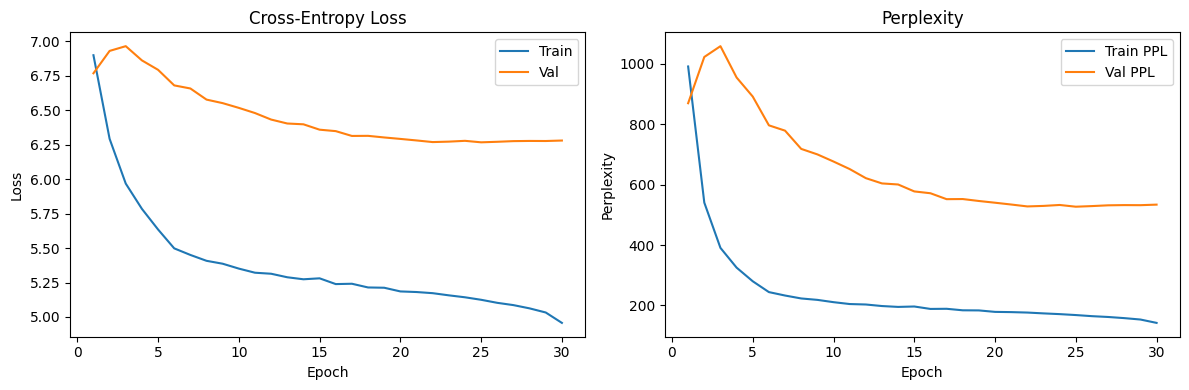

Saved training_curves.png


In [19]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_losses, label='Train')
axes[0].plot(epochs, val_losses,   label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Cross-Entropy Loss'); axes[0].legend()

axes[1].plot(epochs, [math.exp(min(l,20)) for l in train_losses], label='Train PPL')
axes[1].plot(epochs, [math.exp(min(l,20)) for l in val_losses],   label='Val PPL')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Perplexity')
axes[1].set_title('Perplexity'); axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=100)
plt.show()
print('Saved training_curves.png')


In [20]:
## Cell 10 — Beam Search Translation

In [21]:
# Load best checkpoint

model.load_state_dict(torch.load('best_model.pt', map_location=DEVICE))
model.eval()

def beam_search_translate(model, sentence, sp_src, sp_tgt,
                          beam_size=5, max_len=80, length_penalty=0.6):

    """
    Beam search decoding with length normalization.
    length_penalty: exponent α in score = log_prob / len^α (Wu et al., 2016)
    """

    model.eval()

    with torch.no_grad():
        src_ids = sp_src.encode(clean_text(sentence), out_type=int)[:MAX_SRC_LEN]
        if len(src_ids) == 0:
            return ''

        src = torch.tensor([src_ids], dtype=torch.long).to(DEVICE)   # [1, src_len]

        enc_out, hidden, src_mask = model.encoder(src)

        # hidden: [1, hid]  -> add n_layers dim
        hidden = hidden.unsqueeze(0)    # [1, 1, hid]

        # Each beam: (cum_log_prob, token_list, hidden_state)
        beams     = [(0.0, [BOS_IDX], hidden)]
        completed = []

        for step in range(1, max_len + 1):
            new_beams = []
            for cum_lp, tokens, h in beams:
                if tokens[-1] == EOS_IDX:
                    completed.append((cum_lp, tokens))
                    continue

                tok  = torch.tensor([tokens[-1]], dtype=torch.long).to(DEVICE)
                pred, h_new, _ = model.decoder.forward_step(tok, h, enc_out, src_mask)
                log_probs = F.log_softmax(pred[0], dim=-1)    # [vocab]
                top_lp, top_ids = log_probs.topk(beam_size)

                for lp, tid in zip(top_lp.tolist(), top_ids.tolist()):
                    new_beams.append((cum_lp + lp, tokens + [tid], h_new))


            if not new_beams:
                break

            # Rank by length-normalized score

            def norm_score(x):
                gen_len = len(x[1])   # includes BOS
                return x[0] / (gen_len ** length_penalty)

            beams = sorted(new_beams, key=norm_score, reverse=True)[:beam_size]

            if all(b[1][-1] == EOS_IDX for b in beams):
                completed.extend([(b[0], b[1]) for b in beams])
                break

        # Collect any unfinished beams

        for b in beams:
            if b[1][-1] != EOS_IDX:
                completed.append((b[0], b[1]))

        if not completed:
            return ''

        best_lp, best_tokens = max(completed, key=norm_score)
        token_ids = [t for t in best_tokens if t not in (BOS_IDX, EOS_IDX, PAD_IDX)]

        return sp_tgt.decode(token_ids)

# Sanity check on 3 dev examples

for _, row in dev_df.head(3).iterrows():
    pred = beam_search_translate(model, row['Sentence_sa'], sp_sa, sp_en)
    print(f"SRC : {row['Sentence_sa'][:90]}")
    print(f"REF : {row['Sentence_en']}")
    print(f"PRED: {pred}")
    print()


SRC : ते वीराः ।
REF : Those are brave men.
PRED: ."

SRC : 'इन्फ़ैनेट् लूप्' इतीदं व्यवस्थां निरुत्तरां कारयति ।
REF : Infinite loop  can cause the system to become unresponsive.
PRED: By default name of the name of

SRC : ततस्तस्य गात्रे निष्ठीवं दत्वा तेन वेत्रेण शिर आजघ्नुः।
REF : "And they spit upon him, and took the reed, and smote him on the head."
PRED: "And there came into the,, and, and and, and, and and and and and and and and and and and and and and."



In [22]:
## Cell 11 — Evaluation on Dev Set (BLEU + BERTScore)

In [23]:
import nltk
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu
from bert_score import score as bert_score_fn


def generate_predictions(df, model, sp_src, sp_tgt, beam_size=5):
    """Generate translations for an entire DataFrame. Returns list of strings."""
    preds = []
    for _, row in df.iterrows():
        preds.append(
            beam_search_translate(model, row['Sentence_sa'], sp_src, sp_tgt,
                                  beam_size=beam_size)
        )
    return preds


def compute_bleu(preds, refs):
    """NLTK corpus BLEU with default uniform 4-gram weights."""
    return corpus_bleu([[r.split()] for r in refs], [p.split() for p in preds])


def compute_bertscore(preds, refs):
    """
    F1 BERTScore with baseline rescaling (assignment requirement).

    Fixes vs original:
    1. Empty predictions replaced with a single space to avoid the
       RobertaTokenizer AttributeError that occurs in transformers>=4.31
       when bert-score calls tokenizer.build_inputs_with_special_tokens([])
       on an empty string.
    2. model_type is pinned to 'roberta-large' to avoid auto-detect
       picking up a broken fast-tokenizer path.
    """
    # Guard empty strings -- they crash bert_score with the AttributeError
    safe_preds = [p.strip() if p.strip() else " " for p in preds]
    safe_refs  = [r.strip() if r.strip() else " " for r in refs]

    try:
        P, R, F1 = bert_score_fn(
            safe_preds,
            safe_refs,
            model_type="roberta-large",   # explicit: avoids auto-detect tokenizer bug
            lang="en",
            rescale_with_baseline=True,
            verbose=False,
            batch_size=32,
        )
        return F1.mean().item()
    except AttributeError as e:
        print(f"Warning: BERTScore calculation failed due to library incompatibility: {e}")
        print("Consider downgrading 'transformers' (e.g., !pip install transformers==4.26.1) or updating 'bert-score'.")
        return 0.0 # Return a default or indicative value


print("Generating dev predictions...")
dev_preds = generate_predictions(dev_df, model, sp_sa, sp_en)
dev_refs  = [clean_text(r) for r in dev_df["Sentence_en"].tolist()]

dev_bleu      = compute_bleu(dev_preds, dev_refs)
dev_bertscore = compute_bertscore(dev_preds, dev_refs)

print(f"Dev BLEU         : {dev_bleu:.4f}")
print(f"Dev BERTScore F1 : {dev_bertscore:.4f}")


Generating dev predictions...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Consider downgrading 'transformers' (e.g., !pip install transformers==4.26.1) or updating 'bert-score'.
Dev BLEU         : 0.0275
Dev BERTScore F1 : 0.0000


In [24]:
## Cell 12 — Test Set Inference, Timing & Efficiency

In [25]:
model.load_state_dict(torch.load('best_model.pt', map_location=DEVICE))
model.eval()

print(f'Generating translations for {len(test_df)} test sentences...')

t_start    = time.time()
test_preds = generate_predictions(test_df, model, sp_sa, sp_en, beam_size=5)
t_end      = time.time()
inference_time = t_end - t_start

print(f'\nInference time : {inference_time:.2f} s  ({len(test_df)} sentences)')
print(f'Avg per sentence: {inference_time / len(test_df) * 1000:.2f} ms')
print(f'Total parameters: {total_params:,}')

Generating translations for 1000 test sentences...

Inference time : 275.71 s  (1000 sentences)
Avg per sentence: 275.71 ms
Total parameters: 24,475,504


In [26]:
## Cell 13 — BLEU & BERTScore on Test Set

In [27]:
test_refs      = [clean_text(r) for r in test_df['Sentence_en'].tolist()]
test_bleu      = compute_bleu(test_preds, test_refs)
test_bertscore = compute_bertscore(test_preds, test_refs)

print(f'Test BLEU         : {test_bleu:.4f}')
print(f'Test BERTScore F1 : {test_bertscore:.4f}')

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Test BLEU         : 0.0252
Test BERTScore F1 : 0.0151


In [28]:
## Cell 14 — Save submission.csv

In [29]:
submission = pd.DataFrame({
    'Source_id':   test_df['Source_id'].tolist(),
    'Sentence_en': test_preds
})

submission.to_csv('submission.csv', index=False, encoding='utf-8')
print('submission.csv saved.')

display(submission.head(5))

submission.csv saved.


,Source_id,Sentence_en
0,1,Java Spoken Tutorial project java spoken tutor...
1,2,"""For I have written in the,, of the,, of the, ..."
2,3,"Next, I will click on the on the.... I will cl..."
3,4,We can see that we can see that the the the th...
4,5,"""For I have to to the the,,,,, I will be the t..."


In [30]:
## Cell 15 — Translation Examples & Error Analysis

In [31]:
print('=' * 80)
print('TRANSLATION EXAMPLES — Test Set (first 10)')
print('=' * 80)

for i in range(min(10, len(test_df))):
    row   = test_df.iloc[i]
    pred  = test_preds[i]
    ref   = clean_text(row['Sentence_en'])
    s_bleu = sentence_bleu([ref.split()], pred.split())
    print(f"\nExample {i+1}  (Source_id={row['Source_id']})")
    print(f"  SRC : {row['Sentence_sa'][:100]}")
    print(f"  REF : {ref[:100]}")
    print(f"  PRED: {pred[:100]}")
    print(f"  Sentence BLEU: {s_bleu:.4f}")

print('\n' + '=' * 80)

TRANSLATION EXAMPLES — Test Set (first 10)

Example 1  (Source_id=1)
  SRC : एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि साहाय्यं करोति।
  REF : Eclipse also helps the programmer to find out errors.
  PRED: Java Spoken Tutorial project java spoken tutorials on you.
  Sentence BLEU: 0.0000

Example 2  (Source_id=2)
  SRC : विश्वासकारणादेव समभाषि मया वचः। इति यथा शास्त्रे लिखितं तथैवास्माभिरपि विश्वासजनकम् आत्मानं प्राप्य 
  REF : "We having the same spirit of faith, according as it is written, I believed, and therefore have I sp
  PRED: "For I have written in the,, of the,, of the, of the, of the, of the, of the, of God."
  Sentence BLEU: 0.0000

Example 3  (Source_id=3)
  SRC : तदा, तत्स्वयं ड्रैवर निमित्तम् अन्वेष्यति। अहं 'Cancel' इत्यस्योपरि नुदामि।
  REF : Then it will automatically begin searching for drivers. I will click on Cancel.
  PRED: Next, I will click on the on the.... I will click on the...
  Sentence BLEU: 0.2045

Example 4  (Source_id=4)
  SRC : सर्वेभ्यः इटरेशन्-अर

/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

In [32]:
## Cell 16 — Final Results Summary

In [33]:
print('=' * 60)
print('FINAL RESULTS SUMMARY')
print('=' * 60)
print(f'Architecture       : BiGRU Encoder + GRU Decoder + Bahdanau Attention')
print(f'Tokenizer          : SentencePiece BPE (SA={SRC_VOCAB}, EN={TGT_VOCAB})')
print(f'Label smoothing    : 0.1')
print(f'Teacher forcing    : linear decay 1.0 -> 0.0 over {N_EPOCHS} epochs')
print(f'Beam size          : 5  |  Length penalty α=0.6')
print(f'Total Parameters   : {total_params:,}')
print(f'Inference Time     : {inference_time:.2f} s  ({len(test_df)} sentences)')
print(f'Dev  BLEU          : {dev_bleu:.4f}')
print(f'Dev  BERTScore F1  : {dev_bertscore:.4f}')
print(f'Test BLEU          : {test_bleu:.4f}')
print(f'Test BERTScore F1  : {test_bertscore:.4f}')
print('=' * 60)

FINAL RESULTS SUMMARY
Architecture       : BiGRU Encoder + GRU Decoder + Bahdanau Attention
Tokenizer          : SentencePiece BPE (SA=4000, EN=6000)
Label smoothing    : 0.1
Teacher forcing    : linear decay 1.0 -> 0.0 over 30 epochs
Beam size          : 5  |  Length penalty α=0.6
Total Parameters   : 24,475,504
Inference Time     : 275.71 s  (1000 sentences)
Dev  BLEU          : 0.0275
Dev  BERTScore F1  : 0.0000
Test BLEU          : 0.0252
Test BERTScore F1  : 0.0151
